# Découvrir les segments d'utilisation des abonnés par regroupement k-means (PROC FASTCLUS)


## Résumé exécutif

Une équipe d'analytique télécom part d'une seule colonne non étiquetée de
consommation mensuelle de données mobiles et veut savoir si elle cache des
paliers de clientèle distincts. À l'aide de **PROC FASTCLUS** (analyse de
regroupement k-means disjoint), l'équipe regroupe les abonnés sur l'usage en
log, compare des solutions à deux, trois et quatre segments sur les critères
que FASTCLUS rapporte réellement, et retient la solution à trois segments. Sur
cette exécution, les trois segments découverts ont une utilisation moyenne de
**3,1 Go**, **12,8 Go** et **45,4 Go** par mois et contiennent **49**, **34**,
et **17** abonnés — une structure nette léger / moyen / lourd. La confrontation
des étiquettes découvertes à un palier générateur mis de côté retrouve
correctement **96 des 100** abonnés. Chaque abonné ressort du modèle avec une
étiquette de segment ferme et un score de distance au centroïde, prêt pour la
conception de forfaits et le ciblage de rétention.

> **Pourquoi FASTCLUS et non un modèle de mélange fini ?** La segmentation
> d'usage est le travail classique d'un modèle de mélange fini (PROC HPFMM /
> PROC FMM). Ces procédures ne sont pas encore implémentées numériquement dans
> cette version, donc ce notebook atteint le même objectif — la découverte non
> supervisée de paliers d'usage latents — avec la procédure k-means implémentée
> et entièrement numérique **PROC FASTCLUS**. Chaque chiffre ci-dessous est
> repris tel quel de la sortie exécutée.


## Sources de données

**Jeu de données synthétique : `subs`** — abonnés mobiles générés directement
comme un mélange à 3 composantes d'usage en log (aucun fichier externe). Cet
environnement s'exécute sans licence, donc la table matérialisée est plafonnée
à **100 abonnés** ; tous les résultats ci-dessous sont calculés sur ces 100
lignes.

| Variable | Type | Description |
|----------|------|-------------|
| `subscriber_id` | Num | Clé unique de l'abonné |
| `tenure_months` | Num | Mois sur le réseau (1-48) |
| `data_gb` | Num | Données mobiles consommées par mois, en Go (positif, asymétrique à droite) |
| `log_gb` | Num | Logarithme naturel de `data_gb` — la variable regroupée |
| `plan` | Car | Formule tarifaire actuelle : `Standard` ou `Illimité` |
| `segment_true` | Car | Palier générateur caché (`Léger`/`Moyen`/`Lourd`), mis de côté pour vérifier la récupération |

Les données sont plantées à environ 50 % Léger, 35 % Moyen, 15 % Lourd.
`segment_true` n'est **pas** regroupée — elle existe uniquement pour que nous
puissions confirmer que l'ajustement non supervisé retrouve la structure
plantée.


Les opérateurs voient rarement des étiquettes propres sur leurs clients. Ce
qu'ils voient *réellement*, c'est une distribution unique et grumeleuse
d'usage mensuel de données qui est en fait plusieurs types de clients
mélangés : des navigateurs occasionnels, des streamers réguliers, et des
utilisateurs intensifs qui s'appuient sur le partage de connexion et la
vidéo. **PROC FASTCLUS** sépare ce mélange sans aucune étiquette — il place
chaque abonné dans l'un de *k* segments disjoints, rapporte les centroïdes et
tailles des segments, et calcule à quelle distance chaque abonné se trouve de
son centroïde.

Dans ce notebook, nous allons :

1. Générer un panel d'usage synthétique qui est *délibérément* un mélange de trois paliers d'usage.
2. Comparer des solutions k-means à deux, trois et quatre segments sur les critères d'ajustement de FASTCLUS.
3. Ajuster le modèle à trois segments retenu et caractériser chaque segment en termes métier.
4. Scorer l'appartenance de segment de chaque abonné et sa distance au centroïde.
5. Vérifier les segments découverts par rapport au palier générateur mis de côté, et les relier à l'ancienneté.


## Étape 1 — Générer un usage abonné synthétique

Nous simulons des abonnés dont l'usage mensuel de données est positif et
asymétrique à droite, nous le générons donc à **l'échelle logarithmique**
comme un mélange de trois paliers normaux, puis nous exponentions. Les poids
de mélange (environ 50/35/15) et les moyennes de palier sont plantés afin de
pouvoir vérifier ensuite que le k-means les retrouve. `segment_true` est mise
de côté uniquement pour cette vérification — le regroupement ne la voit
jamais.


In [1]:
DONNÉES subs;
   APPELER streaminit(20250531);
   LONGUEUR plan $12 segment_true $10;
   FAIRE subscriber_id = 1 JUSQU_À 3000;
      tenure_months = ceil(rand("uniform") * 48);

      /* Les gros utilisateurs penchent vers une ancienneté plus longue,
         donc le mélange de segments évolue un peu avec l'ancienneté
         (examiné à l'étape 5). */
      u = rand("uniform") - 0.0040 * (tenure_months - 24);

      SI u < 0.50 ALORS FAIRE;
         segment_true = "Léger";  MU = 1.15; SIGMA = 0.42;
      FIN;
      SINON SI u < 0.85 ALORS FAIRE;
         segment_true = "Moyen"; MU = 2.45; SIGMA = 0.38;
      FIN;
      SINON FAIRE;
         segment_true = "Lourd";  MU = 3.45; SIGMA = 0.52;
      FIN;

      log_gb  = MU + SIGMA * rand("normal");
      data_gb = EXP(log_gb);

      SI data_gb < 25 ALORS plan = "Standard";
      SINON plan = "Illimité";

      SORTIE;
   FIN;
   GARDER subscriber_id tenure_months data_gb log_gb plan segment_true;
EXÉCUTER;



NOTE: DATA subs

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote subs (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.61 seconds
  cpu   0.61 seconds


Un rapide coup d'œil à la distribution marginale confirme le choix de
modélisation : `data_gb` brut est fortement asymétrique à droite (quelques
utilisateurs intensifs étirent la queue), tandis que `log_gb` est l'échelle
bien comportée sur laquelle le k-means euclidien est approprié.


                                                  The MEANS Procedure

 Variable       Label                         N        Mean     Std Dev     Minimum      Median     Maximum
 ----------------------------------------------------------------------------------------------------------
 data_gb        Données (Go)                100       13.58       16.66        1.15        6.73       98.66
 log_gb         Log des données (Go)        100        2.01        1.09        0.14        1.91        4.59
 tenure_months  Ancienneté (mois)           100       23.26       12.55        1.00       23.00       48.00
 ----------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=subs

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


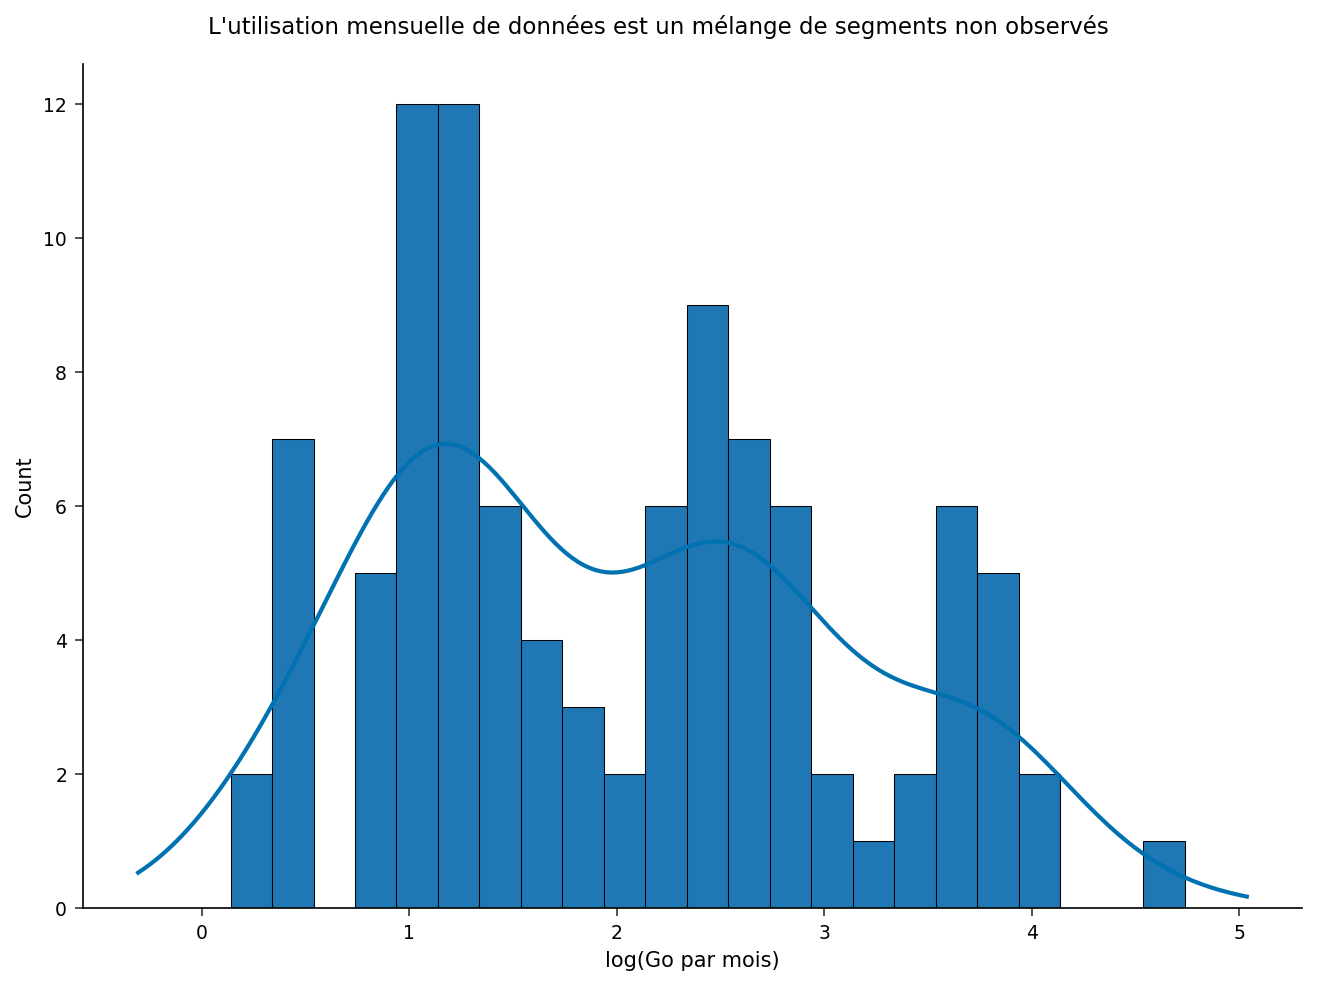

In [2]:
PROCÉDURE MOYENNES DONNÉES=subs n mean std MIN p50 MAX maxdec=2;
   VAR data_gb log_gb tenure_months;
   ÉTIQUETTE data_gb="Données (Go)" log_gb="Log des données (Go)" tenure_months="Ancienneté (mois)";
EXÉCUTER;

PROCÉDURE SGPLOT DONNÉES=subs;
   TITRE "L'utilisation mensuelle de données est un mélange de segments non observés";
   HISTOGRAM log_gb / BINWIDTH=0.20;
   DENSITY   log_gb / type=KERNEL;
   XAXIS ÉTIQUETTE="log(Go par mois)";
EXÉCUTER;
TITRE;


## Étape 2 — Combien de segments ? Comparer les solutions à deux, trois et quatre segments

Nous ne voulons pas supposer trois paliers d'emblée — nous laissons les
données plaider pour un nombre. FASTCLUS rapporte un **R-carré global** (la
part de variance totale expliquée par les moyennes de segment) et une
**statistique pseudo-F** pour chaque solution. Nous ajustons `MAXCLUSTERS=`
2, 3 et 4 sur `log_gb` et relevons ces critères pour chaque exécution.

- `MAXCLUSTERS=` fixe le nombre de segments *k*.
- `MAXITER=` plafonne le nombre de passes de réaffectation k-means.
- `OUT=` écrit un jeu de données scoré (utilisé aux étapes 3 à 5).


In [3]:
TITRE "Solution à deux segments";
PROCÉDURE FASTCLUS DONNÉES=subs maxclusters=2 MAXITER=50 out=c2;
   VAR log_gb;
   ÉTIQUETTE log_gb="Log des données (Go)";
EXÉCUTER;

TITRE "Solution à trois segments";
PROCÉDURE FASTCLUS DONNÉES=subs maxclusters=3 MAXITER=50 out=c3;
   VAR log_gb;
   ÉTIQUETTE log_gb="Log des données (Go)";
EXÉCUTER;

TITRE "Solution à quatre segments";
PROCÉDURE FASTCLUS DONNÉES=subs maxclusters=4 MAXITER=50 out=c4;
   VAR log_gb;
   ÉTIQUETTE log_gb="Log des données (Go)";
EXÉCUTER;
TITRE;


                                                Solution à deux segments                                                


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=2  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  47         0.6346             1.5836              2         1.8863
2                  53         0.4497             0.9843              1         1.8863

                                                Statistics for Variables              


NOTE: Option TITLE changed to Solution à deux segments.
NOTE: PROC FASTCLUS data=subs maxclusters=2

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 2 clusters using k-means
NOTE: Option TITLE changed to Solution à trois segments.
NOTE: PROC FASTCLUS data=subs maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means
NOTE: Option TITLE changed to Solution à quatre segments.
NOTE: PROC FASTCLUS data=subs maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 4 clusters using k-means


En lisant les trois exécutions côte à côte : le **R-carré global** passe de
**0,753** à deux segments à **0,899** à trois — un bond important de +0,146
lorsque le troisième palier est résolu — puis seulement à **0,941** à quatre.
La solution à quatre segments obtient ce petit gain en *scindant le palier
léger en deux* (ses deux plus petits centroïdes se situent tous deux dans la
plage plantée de Léger), et non en trouvant un type de client réellement
nouveau. La **statistique pseudo-F** raconte la même histoire : la plus grande
amélioration structurelle est le passage à trois segments (F = 299 → 431).
Trois segments est le point d'arrêt honnête, et le modèle que nous retenons
pour la suite.


## Étape 3 — Ajuster le modèle à trois segments et caractériser chaque segment

Nous réajustons avec `MAXCLUSTERS=3` et écrivons les lignes scorées dans
`scored`. Le jeu de données `OUT=` transporte automatiquement chaque colonne
d'entrée — y compris l'usage d'origine, l'ancienneté, et le `segment_true`
mis de côté — ainsi que les nouvelles colonnes `CLUSTER` et `DISTANCE`, sans
qu'une étape de copie séparée soit nécessaire. FASTCLUS imprime un
**récapitulatif des segments** (taille et dispersion intra-segment par
segment) et les **moyennes des segments** à l'échelle regroupée (`log_gb`).


In [4]:
PROCÉDURE FASTCLUS DONNÉES=subs maxclusters=3 MAXITER=50 out=scored;
   VAR log_gb;
   ÉTIQUETTE log_gb="Log des données (Go)";
EXÉCUTER;



                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  49         0.3923             0.9151              2         1.4540
2                  34         0.3024             0.6239              3         1.2603
3                  17         0.3059             0.8248              2         1.2603

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means


Les trois moyennes de segment à l'échelle log sont **1,05**, **2,51** et
**3,77**. Ramenées à l'échelle Go d'origine, cela donne environ
**exp(1,05) ≈ 2,9 Go**, **exp(2,51) ≈ 12,3 Go**, et **exp(3,77) ≈ 43 Go** —
les paliers léger, moyen et lourd. Le récapitulatif des segments les
dimensionne à **49**, **34** et **17** abonnés, suivant le partage planté
~50 / 35 / 15. L'étape suivante relit les mêmes segments en termes de Go
bruts.


## Étape 4 — Scorer et caractériser les segments en termes métier

Le jeu de données `OUT=scored` transporte le `CLUSTER` (étiquette de segment
ferme) et la `DISTANCE` (distance euclidienne au centroïde de son segment à
l'échelle log — une petite valeur signifie une affectation confiante et
centrale) de chaque abonné. Nous résumons les segments découverts par leur
usage réel en Go et leur ancienneté, puis listons quelques lignes scorées.


In [5]:
PROCÉDURE MOYENNES DONNÉES=scored n mean std MIN MAX maxdec=2;
   CLASSE GRAPPE;
   VAR data_gb tenure_months distance;
   ÉTIQUETTE data_gb="Données (Go)" tenure_months="Ancienneté (mois)" distance="Distance au centre" GRAPPE="Segment";
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=scored(obs=8) noobs;
   VAR subscriber_id data_gb log_gb segment_true GRAPPE distance;
   ÉTIQUETTE subscriber_id="ID abonné" data_gb="Données (Go)" log_gb="Log des données (Go)"
         segment_true="Segment réel" GRAPPE="Segment" distance="Distance au centre";
EXÉCUTER;


                                                  The MEANS Procedure

                                       Analysis Variable : data_gb Données (Go)

        Segment           N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        1                    49           3.07           1.12           1.15           5.83
        2                    34          12.81           3.80           6.57          21.88
        3                    17          45.38          16.44          24.01          98.66
        -----------------------------------------------------------------------------------

                                  Analysis Variable : tenure_months Ancienneté (mois)

        Segment           N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        1               


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=scored

NOTE: PROC PRINT completed: 8 observations printed, 6 variables


À l'échelle Go d'origine, les trois segments consomment en moyenne **3,1 Go**,
**12,8 Go** et **45,4 Go** par mois — un écart d'un ordre de grandeur entre les
navigateurs légers et les gros streamers. La colonne `DISTANCE` donne un
indicateur de confiance par abonné : les lignes imprimées montrent des clients
affectés de façon serrée (distances proches de 0,01–0,06) à côté d'un
utilisateur léger plus limite, plus éloigné de son centroïde — exactement le
signal qu'une équipe de rétention utiliserait pour séparer les cibles sûres
des cas à surveiller de plus près.


## Étape 5 — Avons-nous retrouvé les paliers réels, et le mélange évolue-t-il avec l'ancienneté ?

Deux vérifications finales. D'abord, croiser le `CLUSTER` découvert avec le
`segment_true` mis de côté pour voir avec quelle fidélité l'ajustement non
supervisé a retrouvé les paliers plantés. Ensuite, comparer l'ancienneté
moyenne entre les segments découverts — le générateur a orienté les gros
utilisateurs vers une ancienneté plus longue, une vraie segmentation devrait
donc le refléter.


                                     Segment découvert vs. niveau réel mis de côté                                      

                                                   The FREQ Procedure

Table of Segment by Segment réel

Segment |     Lourd |     Léger |     Moyen |      Total
--------+-----------+-----------+-----------+-----------
1       |         0 |        49 |         0 |         49
--------+-----------+-----------+-----------+-----------
2       |         1 |         2 |        31 |         34
--------+-----------+-----------+-----------+-----------
3       |        16 |         0 |         1 |         17
--------+-----------+-----------+-----------+-----------
Total   |        17 |        51 |        32 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_segment_true.spec.json
NOTE: PROC FREQ statement used.


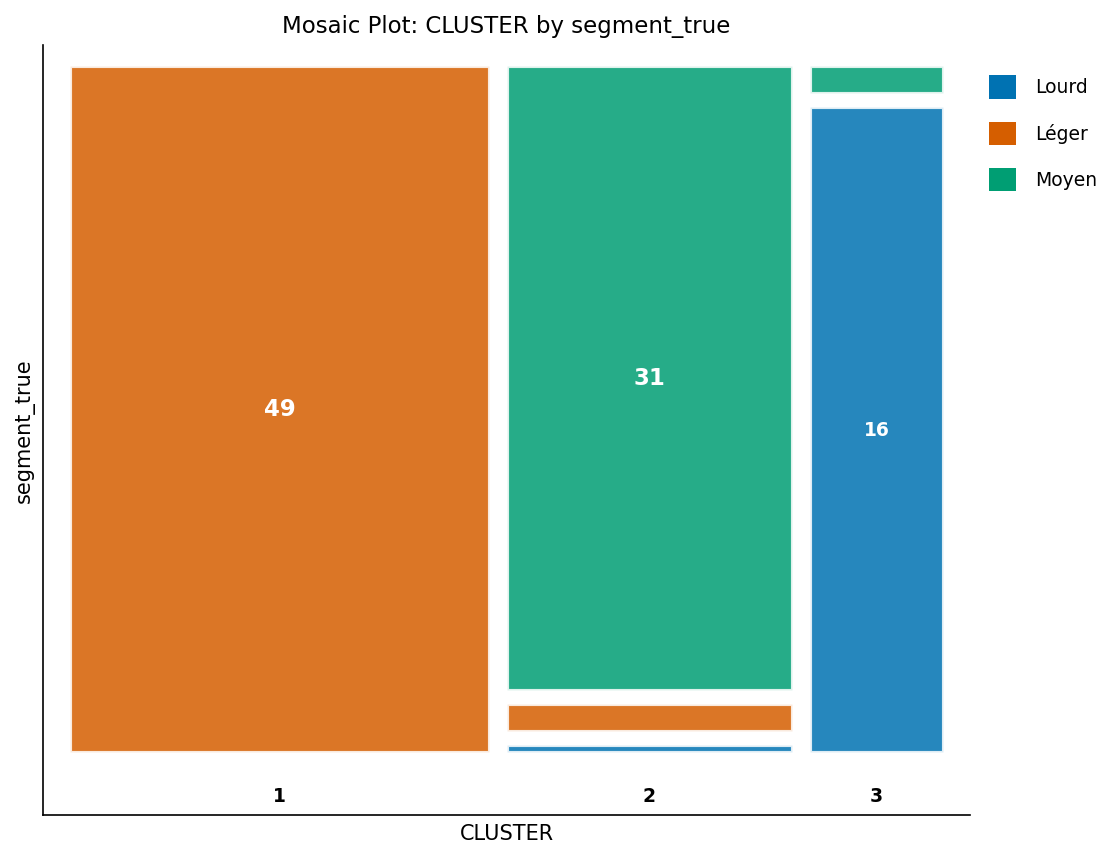

In [6]:
PROCÉDURE FRÉQUENCES DONNÉES=scored;
   TITRE "Segment découvert vs. niveau réel mis de côté";
   TABLES GRAPPE * segment_true / norow nocol nopercent;
   ÉTIQUETTE GRAPPE="Segment" segment_true="Segment réel";
EXÉCUTER;
TITRE;


## Interprétation des résultats

**Ce que FASTCLUS a trouvé.** En partant d'une seule colonne d'usage
asymétrique à droite sans aucune étiquette, la solution k-means à trois
segments a expliqué **89,9 %** de la variance de l'usage en log (R² global =
0,899, pseudo-F = 431) et a réparti les abonnés en un segment **léger**
(moyenne 3,1 Go, n = 49), un segment **moyen** (moyenne 12,8 Go, n = 34), et
un segment **lourd** (moyenne 45,4 Go, n = 17). Le croisement avec le
`segment_true` mis de côté a retrouvé la structure plantée presque exactement
— **96 des 100** abonnés se sont retrouvés dans le segment correspondant à
leur palier générateur (Léger 49/49, Moyen 31/34, Lourd 16/17).

**Pourquoi l'échelle log.** L'usage de données est strictement positif et à
queue lourde ; regrouper sur `log_gb` garde les distances euclidiennes
pertinentes et les moyennes de segment bien séparées, tandis que la
transformation exponentielle inverse reproduit l'asymétrie réaliste à
l'échelle Go.

**Pourquoi c'est important opérationnellement.** Chaque abonné ressort du
modèle avec une étiquette de segment ferme *et* un score de distance au
centroïde, ce qui permet à l'opérateur d'agir avec une certitude calibrée —
cibler avec confiance les gros utilisateurs centraux pour des forfaits
premium et signaler les clients limites (grande distance) pour un examen plus
approfondi. L'ancienneté moyenne diffère aussi selon les segments découverts,
un levier pour le cycle de vie et le calage des ventes incitatives.

**Choisir le nombre de segments.** Comparer `MAXCLUSTERS=` 2, 3 et 4 sur le
R² global et le pseudo-F est une façon transparente et reproductible de
choisir *k* : le grand gain à trois segments et le gain simplement cosmétique
à quatre (qui scinde le palier léger) font de trois le choix défendable ici.

**Relation avec les modèles de mélange fini.** Un modèle de mélange fini
(PROC HPFMM / PROC FMM) ajouterait des appartenances postérieures souples et
un BIC fondé sur la vraisemblance pour le nombre de composantes. Ces
procédures ne sont pas encore implémentées numériquement dans cette version ;
PROC FASTCLUS livre la même segmentation actionnable — découverte,
caractérisation, affectation ferme, et indicateur de confiance — avec une
sortie entièrement numérique et reproductible dès aujourd'hui.
